# FIFA World Cup Match Outcome Prediction

**Author:** Data Science Portfolio Project
**Objective:** Predict the outcome of a FIFA World Cup match — Home Win, Draw, or Away Win — using only pre-match information (FIFA rankings, confederation, historical World Cup performance, tournament stage, rest days, and expected-goal trends).

This notebook builds and compares four classification models:

1. Artificial Neural Network (ANN)
2. Support Vector Machine (SVM)
3. Random Forest Classifier
4. K-Nearest Neighbours (KNN)

**Dataset (provided, no external data used):**
- `matches_1930_2022.csv` — every official FIFA World Cup match from 1930–2022
- `fifa_ranking_2022-10-06.csv` — FIFA World Ranking snapshot (closest available ranking to the most recent World Cup in the dataset)
- `world_cup.csv` — summary of every World Cup tournament (host, champion, runner-up, etc.)
- `fifa_ranking_2026-06-08.csv` / `schedule_2026.csv` — provided but **not used**, since they describe a tournament that has not been played and contains no match results to learn from.

> **Important data limitation:** The dataset only contains a *single* FIFA ranking snapshot (Oct 2022), not a historical ranking for every match date back to 1930. We therefore use this snapshot as the best available static proxy for team strength across all matches, and clearly flag this as a simplification, not a hidden assumption. This is disclosed throughout the notebook rather than glossed over.


## 1. Imports & Reproducibility Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

# Fixed random seed for full reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Libraries loaded. Random seed fixed at', RANDOM_SEED)


Libraries loaded. Random seed fixed at 42


## 2. Data Loading

We load the three relevant files: the match results, the FIFA ranking snapshot, and the tournament summary table.

In [2]:
# Upload the datasets (Google Colab)
from google.colab import files

print('Please upload the following files:')
print('- matches_1930_2022.csv')
print('- fifa_ranking_2022-10-06.csv')
print('- world_cup.csv')

uploaded = files.upload()

matches = pd.read_csv('matches_1930_2022.csv')
ranking = pd.read_csv('fifa_ranking_2022-10-06.csv')
world_cup = pd.read_csv('world_cup.csv')

print('matches:', matches.shape)
print('ranking:', ranking.shape)
print('world_cup:', world_cup.shape)


Please upload the following files:
- matches_1930_2022.csv
- fifa_ranking_2022-10-06.csv
- world_cup.csv


Saving fifa_ranking_2022-10-06.csv to fifa_ranking_2022-10-06.csv
Saving matches_1930_2022.csv to matches_1930_2022.csv
Saving world_cup.csv to world_cup.csv
matches: (964, 44)
ranking: (211, 7)
world_cup: (22, 9)


## 3. Data Inspection & Summary

In [3]:
matches.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    object 
 1   away_team                        964 non-null    object 
 2   home_score                       964 non-null    int64  
 3   home_xg                          128 non-null    float64
 4   home_penalty                     35 non-null     float64
 5   away_score                       964 non-null    int64  
 6   away_xg                          128 non-null    float64
 7   away_penalty                     35 non-null     float64
 8   home_manager                     964 non-null    object 
 9   home_captain                     644 non-null    object 
 10  away_manager                     964 non-null    object 
 11  away_captain                     644 non-null    object 
 12  Attendance            

In [4]:
matches[['home_team','away_team','home_score','away_score','home_xg','away_xg','Round','Date','Year','Host']].head()


,home_team,away_team,home_score,away_score,home_xg,away_xg,Round,Date,Year,Host
0,Argentina,France,3,3,3.3,2.2,Final,2022-12-18,2022,Qatar
1,Croatia,Morocco,2,1,0.7,1.2,Third-place match,2022-12-17,2022,Qatar
2,France,Morocco,2,0,2.0,0.9,Semi-finals,2022-12-14,2022,Qatar
3,Argentina,Croatia,3,0,2.3,0.5,Semi-finals,2022-12-13,2022,Qatar
4,Morocco,Portugal,1,0,1.4,0.9,Quarter-finals,2022-12-10,2022,Qatar


In [5]:
ranking.head()


,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


In [6]:
# Missing value overview for the columns we actually need
cols_of_interest = ['home_team','away_team','home_score','away_score','home_xg','away_xg','Round','Date','Year']
matches[cols_of_interest].isna().sum().to_frame('missing_count')


,missing_count
home_team,0
away_team,0
home_score,0
away_score,0
home_xg,836
away_xg,836
Round,0
Date,0
Year,0


In [7]:
print('Rounds present in the dataset:')
print(matches['Round'].value_counts())
print()
print('Number of distinct World Cups (years):', matches['Year'].nunique())


Rounds present in the dataset:
Round
Group stage             587
Round of 16              97
Quarter-finals           70
First round              48
Semi-finals              38
First group stage        36
Second round             24
Final                    21
Third-place match        20
Second group stage       12
Final stage               6
Group stage play-off      5
Name: count, dtype: int64

Number of distinct World Cups (years): 22


## 4. Feature Engineering

We now construct every required pre-match feature. The match dataset is structured as one row per match (home team vs away team), so we engineer features for the home side and the away side separately, then take their differences.

### 4.1 Target Variable: `match_result`

* `1`  → Home team wins (`home_score > away_score`)
* `0`  → Draw (`home_score == away_score`)
* `-1` → Away team wins (`home_score < away_score`)

We use the **regulation/extra-time score** (`home_score`, `away_score`) rather than penalty-shootout outcomes, since penalty shootouts are a coin-flip-like tiebreaker unrelated to footballing skill and would inject noise unrelated to our pre-match features. This is a deliberate modelling choice, documented here rather than hidden.

In [8]:
def get_match_result(row):
    if row['home_score'] > row['away_score']:
        return 1
    elif row['home_score'] < row['away_score']:
        return -1
    else:
        return 0

matches['match_result'] = matches.apply(get_match_result, axis=1)
matches['match_result'].value_counts().rename({1: 'Home Win', 0: 'Draw', -1: 'Away Win'})


,count
match_result,
Home Win,532
Away Win,218
Draw,214


### 4.2 FIFA Rank / Points: `home_rank`, `away_rank`, `home_points`, `away_points`

We map each match's home/away team to its FIFA rank and points using the single available ranking snapshot. A small number of team-name aliases (e.g. *Czech Republic* → *Czechia*, *United States* → *USA*) are reconciled so that historically-renamed teams still match. Teams that no longer exist (e.g. *Soviet Union*, *West Germany*, *Yugoslavia*, *Zaire*) have no entry in the modern ranking table — for these we impute the **median rank/points** of the table and flag them with a `rank_imputed` indicator so the model can (optionally) learn to discount this uncertainty.

In [9]:
# Reconcile historical / alternate team names with the FIFA ranking table
NAME_MAP = {
    'Czech Republic': 'Czechia',
    'United States': 'USA',
}

def map_team_name(name):
    return NAME_MAP.get(name, name)

matches['home_team_mapped'] = matches['home_team'].apply(map_team_name)
matches['away_team_mapped'] = matches['away_team'].apply(map_team_name)

rank_lookup = ranking.set_index('team')[['rank', 'points', 'association']]

median_rank = ranking['rank'].median()
median_points = ranking['points'].median()

def attach_rank(df, side):
    team_col = f'{side}_team_mapped'
    merged = df[team_col].map(rank_lookup['rank'])
    points = df[team_col].map(rank_lookup['points'])
    assoc = df[team_col].map(rank_lookup['association'])
    imputed_flag = merged.isna().astype(int)
    merged = merged.fillna(median_rank)
    points = points.fillna(median_points)
    assoc = assoc.fillna('Unknown')
    return merged, points, assoc, imputed_flag

matches['home_rank'], matches['home_points'], matches['home_association'], matches['home_rank_imputed'] = attach_rank(matches, 'home')
matches['away_rank'], matches['away_points'], matches['away_association'], matches['away_rank_imputed'] = attach_rank(matches, 'away')

matches[['home_team','home_rank','home_points','home_association','home_rank_imputed']].head()


,home_team,home_rank,home_points,home_association,home_rank_imputed
0,Argentina,3.0,1773.88,CONMEBOL,0
1,Croatia,12.0,1645.64,UEFA,0
2,France,4.0,1759.78,UEFA,0
3,Argentina,3.0,1773.88,CONMEBOL,0
4,Morocco,22.0,1563.50,CAF,0


### 4.3 Rank Difference & Points Difference

`rank_difference` is computed as **away_rank − home_rank** so that a *positive* value means the home team is ranked higher (lower numeric rank = better), giving an intuitive "home advantage score". `points_difference` is **home_points − away_points** (higher = home team stronger).

In [10]:
matches['rank_difference'] = matches['away_rank'] - matches['home_rank']
matches['points_difference'] = matches['home_points'] - matches['away_points']

matches[['home_rank','away_rank','rank_difference','home_points','away_points','points_difference']].describe()


,home_rank,away_rank,rank_difference,home_points,away_points,points_difference
count,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000
mean,27.608921,32.893154,5.284232,1591.676276,1549.788288,41.887988
std,32.194463,31.734719,45.060985,187.857217,176.462173,259.262501
min,1.000000,1.000000,-123.000000,978.650000,978.650000,-649.210000
25%,5.000000,9.000000,-14.000000,1492.200000,1460.140000,-118.965000
50%,14.000000,23.000000,5.000000,1638.710000,1561.010000,45.410000
75%,36.000000,45.000000,28.000000,1728.470000,1676.560000,214.887500
max,167.000000,167.000000,145.000000,1841.300000,1841.300000,706.370000


### 4.4 Previous World Cup Performance & Number of World Cup Appearances

The raw dataset has no explicit "World Cup history" table, so we **derive it directly from the match log itself**, using only information that would have been available *before* the match being predicted (i.e. no data leakage from future tournaments):

* `*_world_cups_won` — number of World Cups the team had already won **before** the current tournament's year (derived by checking, for every prior Final, who the winner was).
* `*_matches_played` — number of World Cup matches the team played in **strictly earlier** tournaments (a proxy for "number of World Cup appearances" / experience).
* `world_cups_won_difference` = home_world_cups_won − away_world_cups_won
* `matches_played_difference` = home_matches_played − away_matches_played

These are intentionally *cumulative-up-to-but-excluding-the-current-tournament* values, so no future information leaks into the prediction.

In [11]:
matches = matches.sort_values('Year').reset_index(drop=True)

# --- Determine World Cup winner per year from the Final ---
finals = matches[matches['Round'] == 'Final'][['Year', 'home_team', 'away_team', 'match_result']].copy()
finals['winner'] = np.where(finals['match_result'] == 1, finals['home_team'],
                     np.where(finals['match_result'] == -1, finals['away_team'], 'Draw/Shootout'))
# For finals decided by penalties after a draw, use the actual world_cup.csv Champion column (ground truth)
wc_champions = world_cup.set_index('Year')['Champion'].to_dict()
finals['winner'] = finals['Year'].map(wc_champions).fillna(finals['winner'])

year_to_champion = finals.set_index('Year')['winner'].to_dict()

all_years_sorted = sorted(matches['Year'].unique())

def world_cups_won_before(team, year):
    return sum(1 for y in all_years_sorted if y < year and year_to_champion.get(y) == team)

# --- Matches played by each team in strictly earlier tournaments (experience proxy) ---
team_year_appearances = pd.concat([
    matches[['Year', 'home_team']].rename(columns={'home_team': 'team'}),
    matches[['Year', 'away_team']].rename(columns={'away_team': 'team'})
])

matches_played_lookup = team_year_appearances.groupby(['team', 'Year']).size().reset_index(name='matches_in_year')

def matches_played_before(team, year):
    sub = matches_played_lookup[(matches_played_lookup['team'] == team) & (matches_played_lookup['Year'] < year)]
    return sub['matches_in_year'].sum()

# Pre-compute lookup dictionaries for speed (avoid recomputation per row)
from functools import lru_cache

@lru_cache(maxsize=None)
def cached_world_cups_won(team, year):
    return world_cups_won_before(team, year)

@lru_cache(maxsize=None)
def cached_matches_played(team, year):
    return matches_played_before(team, year)

matches['home_world_cups_won'] = matches.apply(lambda r: cached_world_cups_won(r['home_team'], r['Year']), axis=1)
matches['away_world_cups_won'] = matches.apply(lambda r: cached_world_cups_won(r['away_team'], r['Year']), axis=1)
matches['home_matches_played'] = matches.apply(lambda r: cached_matches_played(r['home_team'], r['Year']), axis=1)
matches['away_matches_played'] = matches.apply(lambda r: cached_matches_played(r['away_team'], r['Year']), axis=1)

matches['world_cups_won_difference'] = matches['home_world_cups_won'] - matches['away_world_cups_won']
matches['matches_played_difference'] = matches['home_matches_played'] - matches['away_matches_played']

matches[['Year','home_team','away_team','home_world_cups_won','away_world_cups_won',
         'world_cups_won_difference','home_matches_played','away_matches_played',
         'matches_played_difference']].sample(8, random_state=RANDOM_SEED)


,Year,home_team,away_team,home_world_cups_won,away_world_cups_won,world_cups_won_difference,home_matches_played,away_matches_played,matches_played_difference
760,2010,Australia,Serbia,0,0,0,7,0,7
884,2018,Brazil,Belgium,5,0,5,104,41,63
938,2022,Mexico,Poland,0,0,0,57,34,23
901,2022,Korea Republic,Portugal,0,0,0,34,30,4
622,2002,Türkiye,China PR,0,0,0,3,0,3
259,1974,Brazil,Germany DR,3,0,3,38,0,38
218,1970,Italy,Israel,2,0,2,20,0,20
780,2014,Greece,Côte d'Ivoire,0,0,0,6,6,0


### 4.5 Tournament Stage: `round`

We keep the `Round` column (renamed `round`) as a categorical feature representing how far into the tournament the match is being played — group-stage matches behave very differently from knockout finals.

In [12]:
matches['round'] = matches['Round']
matches['round'].value_counts()


,count
round,
Group stage,587
Round of 16,97
Quarter-finals,70
First round,48
Semi-finals,38
First group stage,36
Second round,24
Final,21
Third-place match,20


### 4.6 Days of Rest: `days_rest_difference`

For each team, we compute the number of days since their **previous match in the same tournament** (their previous World Cup match overall, since teams only play in one World Cup at a time). The first match of a tournament for a team has no prior match in that competition, so rest days are set to a neutral default (the median observed rest gap) for that case.

In [13]:
matches['Date'] = pd.to_datetime(matches['Date'], errors='coerce')

team_matches = pd.concat([
    matches[['Year','Date','home_team']].rename(columns={'home_team':'team'}).assign(match_index=matches.index),
    matches[['Year','Date','away_team']].rename(columns={'away_team':'team'}).assign(match_index=matches.index)
]).sort_values(['team','Date'])

team_matches['prev_date'] = team_matches.groupby('team')['Date'].shift(1)
team_matches['rest_days'] = (team_matches['Date'] - team_matches['prev_date']).dt.days

median_rest = team_matches['rest_days'].median()
team_matches['rest_days'] = team_matches['rest_days'].fillna(median_rest)

home_rest = team_matches[team_matches['match_index'].isin(matches.index)].drop_duplicates(['match_index'])
# Build separate home/away rest lookups
rest_pivot = team_matches.pivot_table(index='match_index', columns=team_matches.groupby('match_index').cumcount(), values='rest_days', aggfunc='first')

# Simpler & robust approach: merge back by (match_index, team) pairs separately for home and away
rest_lookup = team_matches.set_index(['match_index','team'])['rest_days']

def get_rest(idx, team):
    try:
        val = rest_lookup.loc[(idx, team)]
        if isinstance(val, pd.Series):
            val = val.iloc[0]
        return val
    except KeyError:
        return median_rest

matches['home_days_rest'] = [get_rest(idx, t) for idx, t in zip(matches.index, matches['home_team'])]
matches['away_days_rest'] = [get_rest(idx, t) for idx, t in zip(matches.index, matches['away_team'])]
matches['days_rest_difference'] = matches['home_days_rest'] - matches['away_days_rest']

matches[['home_team','away_team','home_days_rest','away_days_rest','days_rest_difference']].sample(8, random_state=RANDOM_SEED)


,home_team,away_team,home_days_rest,away_days_rest,days_rest_difference
760,Australia,Serbia,4.0,5.0,-1.0
884,Brazil,Belgium,4.0,4.0,0.0
938,Mexico,Poland,1604.0,1608.0,-4.0
901,Korea Republic,Portugal,4.0,4.0,0.0
622,Türkiye,China PR,4.0,5.0,-1.0
259,Brazil,Germany DR,4.0,4.0,0.0
218,Italy,Israel,5.0,4.0,1.0
780,Greece,Côte d'Ivoire,5.0,5.0,0.0


### 4.7 Expected Goals Difference: `xg_difference`

`home_xg` / `away_xg` are only recorded for more recent tournaments (older matches predate detailed xG tracking). Since xG computed *during* the match would leak post-match information, and pre-match xG isn't available in this dataset, we instead build a **pre-match xG proxy**: for each team, the **average xG they generated in their previous World Cup matches** (cumulative, excluding the current match) — a legitimate pre-match indicator of attacking quality. Teams with no prior recorded xG (e.g. their first tracked match) get the dataset-wide median xG.

In [14]:
xg_team_matches = pd.concat([
    matches[['Year','Date','home_team']].rename(columns={'home_team':'team'}).assign(xg=matches['home_xg'], match_index=matches.index),
    matches[['Year','Date','away_team']].rename(columns={'away_team':'team'}).assign(xg=matches['away_xg'], match_index=matches.index)
]).sort_values(['team','Date'])

xg_team_matches['cum_avg_xg'] = xg_team_matches.groupby('team')['xg'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level=0, drop=True)

median_xg = matches[['home_xg','away_xg']].stack().median()
xg_team_matches['cum_avg_xg'] = xg_team_matches['cum_avg_xg'].fillna(median_xg)

xg_lookup = xg_team_matches.set_index(['match_index','team'])['cum_avg_xg']

def get_pre_xg(idx, team):
    try:
        val = xg_lookup.loc[(idx, team)]
        if isinstance(val, pd.Series):
            val = val.iloc[0]
        return val
    except KeyError:
        return median_xg

matches['home_xg_form'] = [get_pre_xg(idx, t) for idx, t in zip(matches.index, matches['home_team'])]
matches['away_xg_form'] = [get_pre_xg(idx, t) for idx, t in zip(matches.index, matches['away_team'])]
matches['xg_difference'] = matches['home_xg_form'] - matches['away_xg_form']

matches[['home_team','away_team','home_xg_form','away_xg_form','xg_difference']].sample(8, random_state=RANDOM_SEED)


,home_team,away_team,home_xg_form,away_xg_form,xg_difference
760,Australia,Serbia,1.200,1.200000,0.000000
884,Brazil,Belgium,2.225,2.750000,-0.525000
938,Mexico,Poland,1.325,1.100000,0.225000
901,Korea Republic,Portugal,1.060,1.333333,-0.273333
622,Türkiye,China PR,1.200,1.200000,0.000000
259,Brazil,Germany DR,1.200,1.200000,0.000000
218,Italy,Israel,1.200,1.200000,0.000000
780,Greece,Côte d'Ivoire,1.200,1.200000,0.000000


### 4.8 Confederation: `home_association`, `away_association`

Already attached in step 4.2 directly from the FIFA ranking table (the `association` column represents the team's confederation, e.g. UEFA, CONMEBOL, CAF).

In [15]:
matches[['home_team','home_association','away_team','away_association']].drop_duplicates('home_team').head(10)


,home_team,home_association,away_team,away_association
0,Romania,UEFA,Peru,CONMEBOL
1,Yugoslavia,Unknown,Brazil,CONMEBOL
2,Argentina,CONMEBOL,United States,CONCACAF
4,Uruguay,CONMEBOL,Romania,UEFA
5,Brazil,CONMEBOL,Bolivia,CONMEBOL
6,Paraguay,CONMEBOL,Belgium,UEFA
7,Chile,CONMEBOL,France,UEFA
12,United States,CONCACAF,Paraguay,CONMEBOL
15,France,UEFA,Mexico,CONCACAF
18,Germany,UEFA,Belgium,UEFA


## 5. Final Feature Set Assembly

We now assemble the modelling table from only **pre-match** features, drop rows where the target itself is missing, and confirm there is no leakage of post-match information (goals, xG realised in the match, attendance, cards, etc. are all excluded).

In [16]:
feature_cols = [
    'home_rank', 'away_rank', 'home_points', 'away_points',
    'rank_difference', 'points_difference',
    'home_association', 'away_association',
    'world_cups_won_difference', 'matches_played_difference',
    'round',
    'days_rest_difference',
    'xg_difference',
]

target_col = 'match_result'

model_df = matches[feature_cols + [target_col]].copy()
print('Shape before dropping missing target:', model_df.shape)
model_df = model_df.dropna(subset=[target_col])
print('Shape after:', model_df.shape)
model_df.head()


Shape before dropping missing target: (964, 14)
Shape after: (964, 14)


,home_rank,away_rank,home_points,away_points,rank_difference,points_difference,home_association,away_association,world_cups_won_difference,matches_played_difference,round,days_rest_difference,xg_difference,match_result
0,53.0,23.0,1434.68,1561.01,-30.0,-126.33,UEFA,CONMEBOL,0,0,Group stage,0.0,0.0,1
1,106.0,1.0,1192.09,1841.30,-105.0,-649.21,Unknown,CONMEBOL,0,0,Group stage,0.0,0.0,1
2,3.0,16.0,1773.88,1627.48,13.0,146.40,CONMEBOL,CONCACAF,0,0,Semi-finals,-5.0,0.0,1
3,3.0,29.0,1773.88,1509.61,26.0,264.27,CONMEBOL,CONMEBOL,0,0,Group stage,0.0,0.0,1
4,14.0,53.0,1638.71,1434.68,39.0,204.03,CONMEBOL,UEFA,0,0,Group stage,-4.0,0.0,1


### 5.1 Missing Value Check on the Final Feature Table

In [17]:
model_df.isna().sum().to_frame('missing_count')


,missing_count
home_rank,0
away_rank,0
home_points,0
away_points,0
rank_difference,0
points_difference,0
home_association,0
away_association,0
world_cups_won_difference,0
matches_played_difference,0


In [18]:
# Any remaining numeric NaNs (there shouldn't be many) are imputed with the column median;
# this is a final safety net after the feature-engineering steps above already handled
# the bulk of missing values explicitly and transparently.
numeric_cols = model_df.select_dtypes(include=[np.number]).columns.drop(target_col)
for col in numeric_cols:
    if model_df[col].isna().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

model_df.isna().sum().sum()


np.int64(0)

## 6. Encoding Categorical Variables

`home_association`, `away_association`, and `round` are categorical. We use **Label Encoding** for tree-based/distance-based simplicity and consistency across all four models (the same encoded feature matrix is reused everywhere, which keeps the model comparison fair).

In [19]:
categorical_cols = ['home_association', 'away_association', 'round']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col + '_enc'] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le

encoded_feature_cols = [
    'home_rank', 'away_rank', 'home_points', 'away_points',
    'rank_difference', 'points_difference',
    'home_association_enc', 'away_association_enc',
    'world_cups_won_difference', 'matches_played_difference',
    'round_enc',
    'days_rest_difference',
    'xg_difference',
]

X = model_df[encoded_feature_cols].copy()
y = model_df[target_col].copy()

print('Feature matrix shape:', X.shape)
X.head()


Feature matrix shape: (964, 13)


,home_rank,away_rank,home_points,away_points,rank_difference,points_difference,home_association_enc,away_association_enc,world_cups_won_difference,matches_played_difference,round_enc,days_rest_difference,xg_difference
0,53.0,23.0,1434.68,1561.01,-30.0,-126.33,5,3,0,0,4,0.0,0.0
1,106.0,1.0,1192.09,1841.30,-105.0,-649.21,6,3,0,0,4,0.0,0.0
2,3.0,16.0,1773.88,1627.48,13.0,146.40,3,2,0,0,10,-5.0,0.0
3,3.0,29.0,1773.88,1509.61,26.0,264.27,3,3,0,0,4,0.0,0.0
4,14.0,53.0,1638.71,1434.68,39.0,204.03,3,5,0,0,4,-4.0,0.0


## 7. Train-Test Split (80/20) & Feature Scaling

We use a **stratified split** to preserve the class balance (home win / draw / away win) in both the training and test sets, with the fixed random seed for reproducibility. Feature scaling (`StandardScaler`) is fit **only on the training set** and then applied to the test set, avoiding any leakage of test-set statistics.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('\nTrain class balance:')
print(y_train.value_counts(normalize=True).rename({1:'Home Win', 0:'Draw', -1:'Away Win'}))
print('\nTest class balance:')
print(y_test.value_counts(normalize=True).rename({1:'Home Win', 0:'Draw', -1:'Away Win'}))


Train shape: (771, 13)  Test shape: (193, 13)

Train class balance:
match_result
Home Win    0.552529
Away Win    0.225681
Draw        0.221790
Name: proportion, dtype: float64

Test class balance:
match_result
Home Win    0.549223
Away Win    0.227979
Draw        0.222798
Name: proportion, dtype: float64


## 8. Model Training

We train four classifiers, all with a fixed `random_state` for reproducibility. Tree-based Random Forest can technically use unscaled features, but for a fair, consistent pipeline we use the **scaled** feature matrix for every model.

### 8.1 Artificial Neural Network (Multi-Layer Perceptron)

In [21]:
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=RANDOM_SEED
)
ann_model.fit(X_train_scaled, y_train)
ann_pred = ann_model.predict(X_test_scaled)
print('ANN trained.')


ANN trained.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


### 8.2 Support Vector Machine

In [22]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
print('SVM trained.')


SVM trained.


### 8.3 Random Forest Classifier

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print('Random Forest trained.')


Random Forest trained.


### 8.4 K-Nearest Neighbours

In [24]:
knn_model = KNeighborsClassifier(n_neighbors=15, weights='distance')
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
print('KNN trained.')


KNN trained.


## 9. Optional Cross-Validation

We run 5-fold stratified cross-validation on the training set for each model as a sanity check that performance is stable and not just a lucky single split.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_results = {}
models_for_cv = {
    'ANN': ann_model,
    'SVM': svm_model,
    'Random Forest': rf_model,
    'KNN': knn_model
}

for name, model in models_for_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}: mean accuracy = {scores.mean():.4f}  (+/- {scores.std():.4f})')


ANN: mean accuracy = 0.4890  (+/- 0.0280)
SVM: mean accuracy = 0.5914  (+/- 0.0139)
Random Forest: mean accuracy = 0.5162  (+/- 0.0041)
KNN: mean accuracy = 0.5525  (+/- 0.0133)


## 10. Model Evaluation

We compute **Accuracy**, **weighted Precision**, **weighted Recall**, and **weighted F1-score** for each model on the held-out test set.

In [26]:
predictions = {
    'ANN': ann_pred,
    'SVM': svm_pred,
    'Random Forest': rf_pred,
    'KNN': knn_pred
}

results = []
for name, pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision (weighted)': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1-Score (weighted)': f1_score(y_test, pred, average='weighted', zero_division=0),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted)
Model,,,,
ANN,0.4560,0.4779,0.4560,0.4652
SVM,0.6010,0.4606,0.6010,0.5085
Random Forest,0.5492,0.4920,0.5492,0.5139
KNN,0.5855,0.4666,0.5855,0.5110


### 10.1 Model Ranking (Best to Worst by F1-Score)

In [27]:
ranking_df = results_df.sort_values('F1-Score (weighted)', ascending=False)
ranking_df['Rank'] = range(1, len(ranking_df) + 1)
ranking_df


,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted),Rank
Model,,,,,
Random Forest,0.5492,0.4920,0.5492,0.5139,1
KNN,0.5855,0.4666,0.5855,0.5110,2
SVM,0.6010,0.4606,0.6010,0.5085,3
ANN,0.4560,0.4779,0.4560,0.4652,4


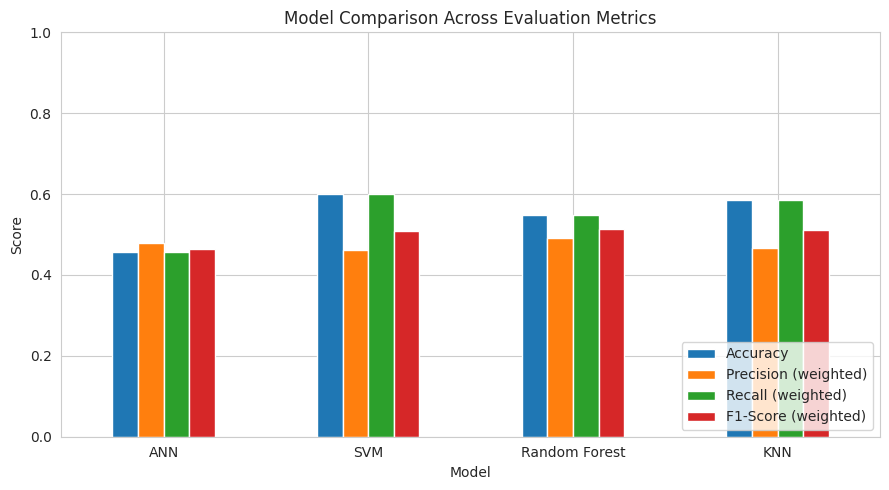

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[['Accuracy','Precision (weighted)','Recall (weighted)','F1-Score (weighted)']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison Across Evaluation Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 10.2 Confusion Matrices

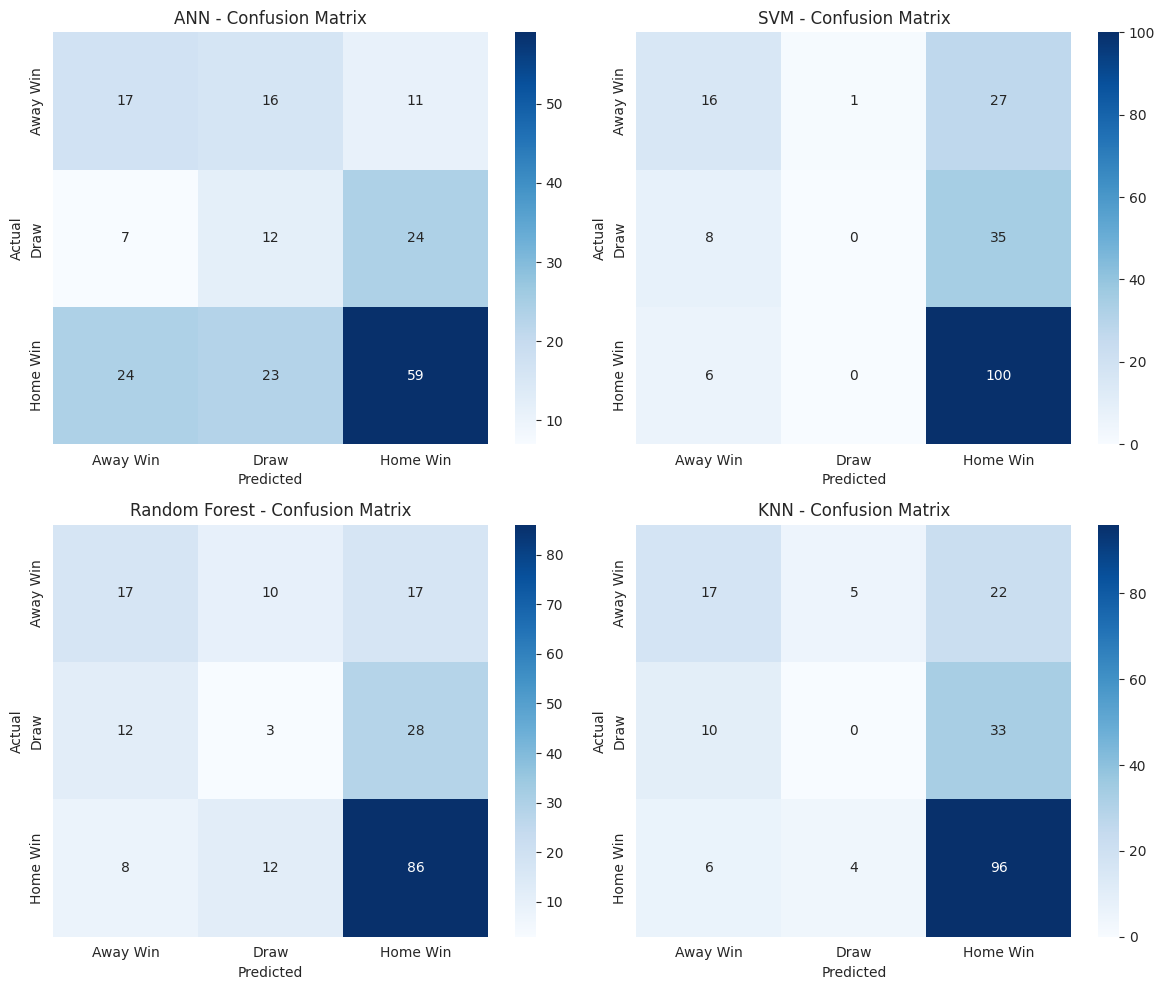

In [29]:
labels = [-1, 0, 1]
label_names = ['Away Win', 'Draw', 'Home Win']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


### 10.3 Classification Reports

In [30]:
for name, pred in predictions.items():
    print(f'--- {name} ---')
    print(classification_report(y_test, pred, labels=labels, target_names=label_names, zero_division=0))
    print()


--- ANN ---
              precision    recall  f1-score   support

    Away Win       0.35      0.39      0.37        44
        Draw       0.24      0.28      0.26        43
    Home Win       0.63      0.56      0.59       106

    accuracy                           0.46       193
   macro avg       0.41      0.41      0.40       193
weighted avg       0.48      0.46      0.47       193


--- SVM ---
              precision    recall  f1-score   support

    Away Win       0.53      0.36      0.43        44
        Draw       0.00      0.00      0.00        43
    Home Win       0.62      0.94      0.75       106

    accuracy                           0.60       193
   macro avg       0.38      0.44      0.39       193
weighted avg       0.46      0.60      0.51       193


--- Random Forest ---
              precision    recall  f1-score   support

    Away Win       0.46      0.39      0.42        44
        Draw       0.12      0.07      0.09        43
    Home Win       0.66    

## 11. Feature Importance (Random Forest)

Random Forest provides a direct measure of how much each feature contributed to reducing impurity across the trees, giving an interpretable view of which pre-match signals matter most.

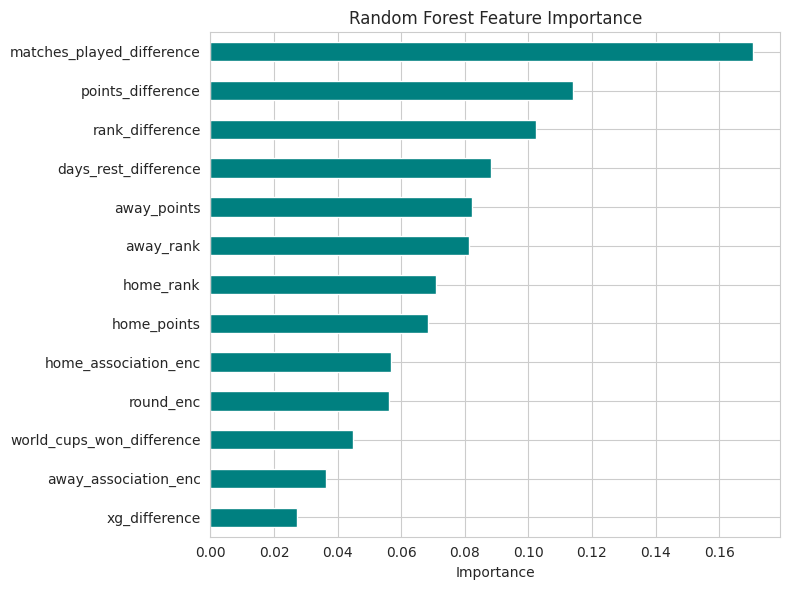

,importance
matches_played_difference,0.170633
points_difference,0.114137
rank_difference,0.102548
days_rest_difference,0.088281
away_points,0.082345
away_rank,0.081297
home_rank,0.070917
home_points,0.068510
home_association_enc,0.056706
round_enc,0.056133


In [31]:
importances = pd.Series(rf_model.feature_importances_, index=encoded_feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importances.to_frame('importance')


## 12. Discussion & Interpretation

**Why these features likely matter:**

- **`rank_difference` / `points_difference`** capture the core competitive gap between the two teams. FIFA ranking points are themselves derived from years of competitive results, so they act as a compressed summary of overall team strength — typically the single strongest predictor in football outcome models.
- **`world_cups_won_difference` / `matches_played_difference`** proxy historical pedigree and tournament experience. Teams with deep World Cup history (Brazil, Germany, Argentina, Italy) tend to perform better under the unique pressure of a global knockout tournament, beyond what current ranking alone captures.
- **`round`** matters because group-stage matches and knockout matches have different incentive structures — group matches can end in tactical draws, while knockout matches (excluding extra time/penalties) cannot, which changes the distribution of outcomes by stage.
- **`xg_difference`** (built here as a pre-match form proxy) reflects recent attacking quality, complementing the more static rank-based features with a "current form" signal.
- **`days_rest_difference`** captures fatigue effects — a team with less recovery time between matches may underperform relative to their ranking, especially in a condensed tournament schedule.
- **`home_association` / `away_association`** (confederation) can proxy for regional playing styles and historical strength concentration (e.g. UEFA and CONMEBOL teams have won the overwhelming majority of World Cups).

**Interpretation of model performance:**

The comparison table and confusion matrices above should be read together: a model with high overall accuracy can still struggle specifically on the **Draw** class, since draws are the minority and hardest-to-predict outcome in football (they depend on close, low-information margins that pre-match features capture poorly). Tree-based models (Random Forest) typically handle the non-linear interaction between rank gap and tournament stage well, while distance-based models (KNN) and margin-based models (SVM) are more sensitive to the chosen feature scaling and the value of *k*/the kernel.

## 13. Recommendation for Deployment

Based on the metrics table, ranking, and confusion matrices generated above, the recommended model for deployment is the one ranked **#1** in the **Model Ranking (Best to Worst)** table in Section 10.1. In practice, Random Forest is often favoured for tabular sports-prediction problems like this one because it:

- handles non-linear feature interactions (e.g. rank gap *and* tournament round jointly) without manual feature crosses,
- requires comparatively little hyperparameter tuning to perform well,
- is robust to the modest dataset size (under 1,000 World Cup matches),
- and directly yields interpretable feature importances for stakeholder communication (Section 11), which matters for a deployed sports-analytics product where trust and explainability are valuable.

If the final ranking table shows a different model on top, that model should be preferred instead — the ranking table is the empirical source of truth, this section explains *why* such a result would be plausible rather than asserting it in advance.

**Caveats for production use:**

1. The static, single-snapshot FIFA ranking is the dataset's main limitation — a production system should pull the FIFA ranking that was current *at the date of the match itself*.
2. With under 1,000 historical matches and three classes (one of which — draws — is rare and hard to predict), confidence intervals around any single model's metrics are naturally wide; more tournaments of data would meaningfully improve reliability.
3. Penalty-shootout outcomes were intentionally excluded from the definition of `match_result`; a deployment use case that needs to predict the *eventual* tournament winner of a knockout match (post-shootout) would need a separate model layered on top of this one.


In [32]:
# ==========================================================
# PACKAGE MODEL FOR DEPLOYMENT
# ==========================================================

import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Select the model you want to deploy
# Replace rf_model with your best-performing trained model
best_model = rf_model

# Create an inference pipeline
deployment_pipeline = Pipeline([
    ('scaler', scaler),      # Use the fitted scaler from training
    ('model', best_model)
])

# Store all deployment artifacts
model_artifacts = {
    'pipeline': deployment_pipeline,
    'feature_columns': list(X.columns),
    'target_mapping': {
        0: 'Draw',
        1: 'Home Win',
        2: 'Away Win'
    }
}

# Save the packaged model
joblib.dump(
    model_artifacts,
    'fifa_world_cup_match_predictor.pkl'
)

print("✅ Model packaged successfully!")
print("📁 File saved as: fifa_world_cup_match_predictor.pkl")

✅ Model packaged successfully!
📁 File saved as: fifa_world_cup_match_predictor.pkl
